In [1]:
from google.colab import files
uploaded = files.upload()


Saving train.csv to train.csv


In [2]:
import pandas as pd

df = pd.read_csv("train.csv")
df.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df[['GrLivArea', 'BedroomAbvGr', 'FullBath', 'SalePrice']].head()


,GrLivArea,BedroomAbvGr,FullBath,SalePrice
0,1710,3,2,208500
1,1262,3,2,181500
2,1786,3,2,223500
3,1717,3,1,140000
4,2198,4,2,250000


In [4]:
X = df[['GrLivArea', 'BedroomAbvGr', 'FullBath']]  # variables indépendantes
y = df['SalePrice']  # variable cible


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [6]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [7]:
y_pred = model.predict(X_test)


In [8]:
from sklearn.metrics import mean_squared_error, r2_score

print("Erreur quadratique moyenne (MSE) :", mean_squared_error(y_test, y_pred))
print("Score R² :", r2_score(y_test, y_pred))


Erreur quadratique moyenne (MSE) : 2806426667.247853
Score R² : 0.6341189942328371


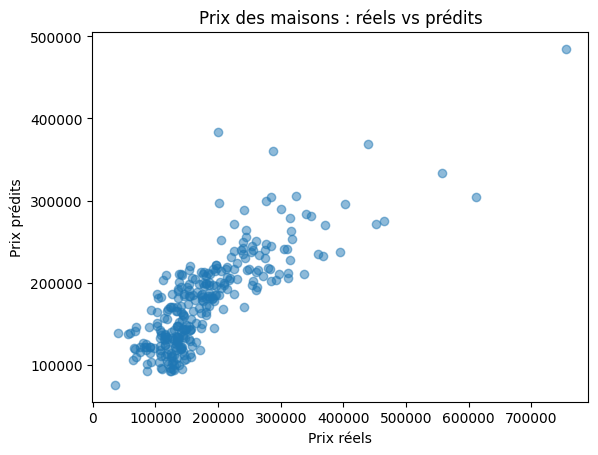

In [9]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Prix réels")
plt.ylabel("Prix prédits")
plt.title("Prix des maisons : réels vs prédits")
plt.show()


In [11]:
!pip install gradio

import gradio as gr
import pandas as pd
from sklearn.linear_model import LinearRegression

# Charger les données et entraîner le modèle
df = pd.read_csv("train.csv")
X = df[['GrLivArea', 'BedroomAbvGr', 'FullBath']]
y = df['SalePrice']
model = LinearRegression().fit(X, y)

# Fonction de prédiction
def predict_price(gr_liv_area, bedroom, full_bath):
    input_data = [[gr_liv_area, bedroom, full_bath]]
    prediction = model.predict(input_data)[0]
    return f"🏡 Prix estimé : **{round(prediction)} $**"

# Interface Gradio avancée
with gr.Blocks() as demo:
    gr.Markdown("# 🏠 Estimation de prix immobilier\nDonnez les détails ci-dessous pour estimer le prix.")

    with gr.Row():
        gr_liv_area = gr.Slider(500, 4500, label="Surface habitable (GrLivArea)")
        bedroom = gr.Slider(0, 10, step=1, label="Nombre de chambres (BedroomAbvGr)")
        full_bath = gr.Slider(0, 5, step=1, label="Salles de bain (FullBath)")

    predict_btn = gr.Button("Prédire le prix 🧮")
    output = gr.Markdown()

    predict_btn.click(fn=predict_price, inputs=[gr_liv_area, bedroom, full_bath], outputs=output)

demo.launch()


It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e1c73023cf0d075c87.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
